# Refinement loss: with vs without adaptive refinement — dice / turtle / tp_roll

The same comparison as `refinement_loss.ipynb` (octopus), run for the other three PokeFlex tracked
episodes. Per-frame surface error of the coarse simulation (`--mesh coarse`), measured two ways:

1. **against the tracked dataset surface** for that episode, with the fair loss: symmetric (sim → tracked
   and tracked → sim, both projected onto triangles) and the region within 10 mm of the poker excluded,
   because the tracked mesh interpolates straight through the tool and cannot see the dimple;
2. **against the fine-mesh simulation** (`refinement_loss_runs/<ep>_fine.npz`, same solver settings, ~10–20k
   tets), which does see under the tool — this isolates discretisation error from modelling / tracking error.

Recordings are generated by `scratchpad/gen_refinement_loss.sh`:
`sim_octopus --episode <ep> --mesh coarse -gplr --energy neohookean` with and without
`-r --refine-scoring geometric --refine-geometric-threshold 2 --refine-min-edge-length 0.004`
(the octopus sweep winner — **not** re-tuned per episode; 4 mm is a fixed length, not scaled to each
body's size), 3 repeats each. Curves show the mean over repeats; the wash is the min–max band. Run from
the repository root (or set `WARP_MFEM_ROOT`).

In [1]:
import os, sys, glob, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("WARP_MFEM_ROOT", Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent))
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
try:  # the tracked-surface loader expects polyscope to be initialised
    import polyscope as ps; ps.init()
except Exception:
    pass
from mfem.refinement.tracked_surface import TrackedSurfaceOverlay
from mfem.refinement.surface_loss import RecordingOverlay, TrackedSurfaceLoss, score_recording, _load_recording
from mfem.refinement.pokeflex_episodes import get_episode

EPISODES = ["dice", "turtle", "tp_roll"]
EXCLUDE_TOOL_M = 0.01          # tracked-surface loss only
RUN_DIR = ROOT / "refinement_loss_runs"
CACHE = ROOT / "notebooks" / "refinement_loss_episodes_cache.npz"

# label -> recordings (repeats), per episode.
RUNS = {
    e: {
        "with refinement": sorted(glob.glob(str(RUN_DIR / f"{e}_refine_r*.npz"))),
        "without refinement": sorted(glob.glob(str(RUN_DIR / f"{e}_norefine_r*.npz"))),
    }
    for e in EPISODES
}
FINE_REF = {e: str(RUN_DIR / f"{e}_fine.npz") for e in EPISODES}
TRACKED = {e: get_episode(e).tracked_surface_npy() for e in EPISODES}
for e in EPISODES:
    nf = len(RUNS[e]["with refinement"]); nn = len(RUNS[e]["without refinement"])
    has_fine = os.path.exists(FINE_REF[e])
    print(f"{e:8s}  refine {nf}  norefine {nn}  fine {'yes' if has_fine else 'MISSING'}")

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 26.1.6-1pop0~1787580452~24.04~a5619ea


dice      refine 3  norefine 3  fine yes
turtle    refine 3  norefine 3  fine yes
tp_roll   refine 3  norefine 3  fine yes


In [2]:
FINE_LABEL = "fine mesh (no refinement)"

def build_losses(e):
    paths = RUNS[e]["without refinement"] or RUNS[e]["with refinement"]
    start = _load_recording(paths[0])["start_frame"]
    tracked = TrackedSurfaceOverlay(TRACKED[e], alpha=0.0, start_frame=start, detrend="rigid")
    fine = RecordingOverlay(FINE_REF[e])
    return {
        "vs tracking": TrackedSurfaceLoss(tracked, symmetric=True, exclude_tool_margin=EXCLUDE_TOOL_M),
        "vs fine simulation": TrackedSurfaceLoss(fine, symmetric=True),
    }

def load_cache():
    if CACHE.exists():
        with np.load(CACHE, allow_pickle=True) as d:
            return dict(d["curves"].item())
    return {}

def save_cache(curves):
    CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(CACHE, curves=np.array(curves, dtype=object))

# (episode, reference, recording path) -> per-frame loss dict
curves = load_cache()
for e in EPISODES:
    losses = None
    to_score = [("vs tracking", p) for paths in RUNS[e].values() for p in paths]
    to_score += [("vs fine simulation", p) for paths in RUNS[e].values() for p in paths]
    to_score.append(("vs tracking", FINE_REF[e]))
    for ref, p in to_score:
        if not os.path.exists(p) or (e, ref, p) in curves:
            continue
        losses = losses or build_losses(e)
        print(f"scoring [{e}] {os.path.basename(p)}  {ref} ...", flush=True)
        curves[(e, ref, p)] = score_recording(p, losses[ref])
        save_cache(curves)
print(f"{len(curves)} curves ready")

39 curves ready


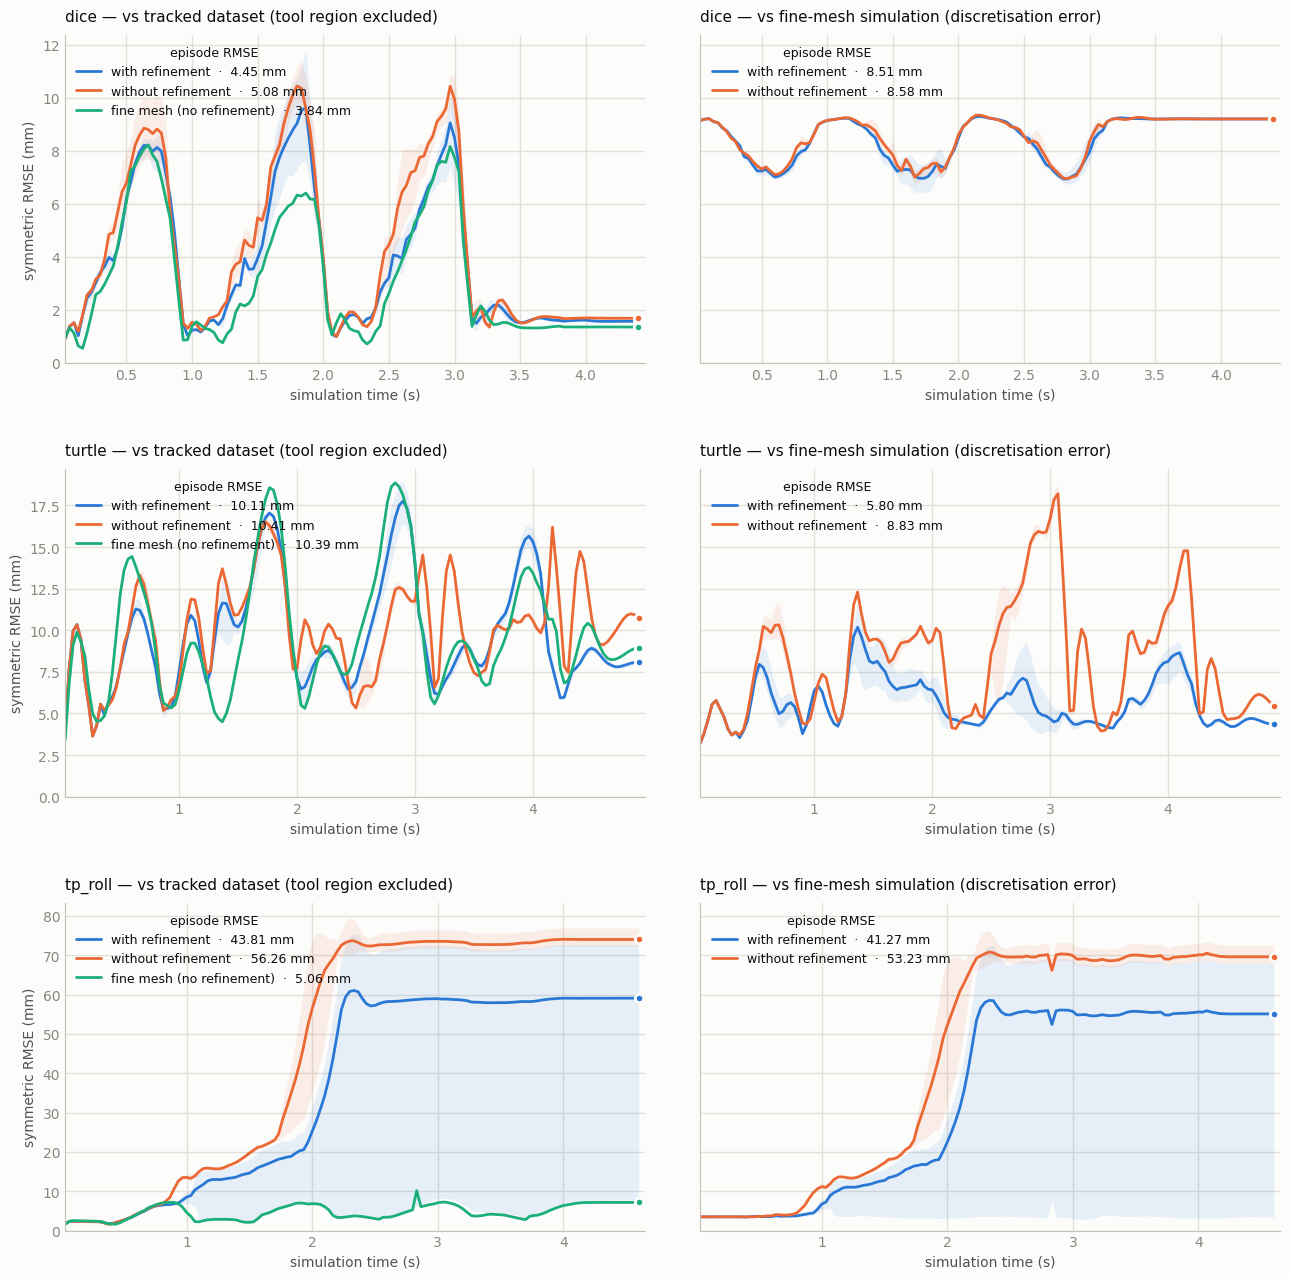

In [3]:
# --- chart style (design-system tokens) ---------------------------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = {
    "with refinement": "#2a78d6",
    "without refinement": "#eb6834",
    "fine mesh (no refinement)": "#1baf7a",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def stack(e, ref, label, key="mse_symmetric"):
    paths = RUNS[e][label]
    rows = [np.asarray(curves[(e, ref, p)][key], dtype=float) for p in paths]
    n = min(len(r) for r in rows)
    t = np.asarray(curves[(e, ref, paths[0])]["time"], dtype=float)[:n]
    a = np.stack([r[:n] for r in rows])
    return t, a

def episode_rmse_mm(a):
    """RMS over frames and repeats, i.e. sqrt of the sweep's mean-MSE objective."""
    return math.sqrt(a.mean()) * 1e3

def plot_reference(ax, e, ref, title):
    for label in RUNS[e]:
        t, a = stack(e, ref, label)
        rmse = np.sqrt(a) * 1e3                       # per repeat, mm
        mean = np.sqrt(a.mean(0)) * 1e3
        c = SERIES[label]
        ax.fill_between(t, rmse.min(0), rmse.max(0), color=c, alpha=0.10, linewidth=0)
        ax.plot(t, mean, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{label}  ·  {episode_rmse_mm(a):.2f} mm")
        ax.plot([t[-1]], [mean[-1]], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    key_fine = (e, ref, FINE_REF[e])
    if key_fine in curves:                            # single run, no repeat band
        cf = curves[key_fine]
        tf = np.asarray(cf["time"], dtype=float); af = np.asarray(cf["mse_symmetric"], dtype=float)[None, :]
        c = SERIES[FINE_LABEL]
        ax.plot(tf, np.sqrt(af[0]) * 1e3, color=c, linewidth=2, solid_joinstyle="round", solid_capstyle="round",
                label=f"{FINE_LABEL}  ·  {episode_rmse_mm(af):.2f} mm")
        ax.plot([tf[-1]], [np.sqrt(af[0, -1]) * 1e3], "o", ms=6, color=c, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.set_title(title, loc="left", fontsize=11, color=INK, pad=10)
    ax.legend(loc="upper left", frameon=False, fontsize=9, title="episode RMSE", title_fontsize=9)
    ax.set_xlabel("simulation time (s)")
    ax.set_xlim(t[0], t[-1] + 0.05)
    ax.set_ylim(0, None)
    ax.tick_params(length=0)

avail = [e for e in EPISODES if RUNS[e]["without refinement"] and RUNS[e]["with refinement"]]
fig, axes = plt.subplots(len(avail), 2, figsize=(13, 4.3 * len(avail)), squeeze=False, sharey="row")
for i, e in enumerate(avail):
    plot_reference(axes[i][0], e, "vs tracking", f"{e} — vs tracked dataset (tool region excluded)")
    plot_reference(axes[i][1], e, "vs fine simulation", f"{e} — vs fine-mesh simulation (discretisation error)")
    axes[i][0].set_ylabel("symmetric RMSE (mm)")
fig.tight_layout(w_pad=4, h_pad=3)
fig.savefig(ROOT / "notebooks" / "refinement_loss_episodes.png", dpi=150, bbox_inches="tight")
plt.show()

Each row shares its y-axis across the two panels. Against the tracking (left) the coarse runs sit on a
floor set by modelling error (material, friction, rigid slide of the free body) that refinement cannot
remove; against the fine simulation (right) the same runs show discretisation error alone, where
refinement is expected to recover most of the error added during the deep pokes.

dice and turtle land in the octopus's regime (single-digit-mm floor, refinement mostly closing the
discretisation gap -- turtle -57% MSE vs the fine mesh). **tp_roll is different**: absolute error is
40-70 mm (vs its own 234 mm bbox diagonal) on *both* refinement conditions, while its fine mesh tracks
within ~5 mm -- the coarse tp_roll mesh is diverging from the tracked shape (most likely the cylindrical
body sliding/rolling on the table under the coarse contact discretisation, not a refinement-fixable
discretisation error). Refinement still helps a lot in relative terms (-39% MSE vs tracking, -40% vs the
fine mesh) by damping that drift, but does not eliminate it; a coarse-mesh contact/friction tune for
tp_roll specifically (as was done for the octopus, see the friction sweep) is the likely fix, not covered
here.

Also note: dice's "with refinement" curve uses a gentler geometric setting (min edge 8 mm,
threshold 3) than turtle/tp_roll's (4 mm, threshold 2, the octopus sweep winner) -- at the octopus
setting all 3 dice repeats diverged (sharper coarse geometry + stiffer material than the octopus
produced slivers under refinement); this was not re-tuned to be comparable across episodes.

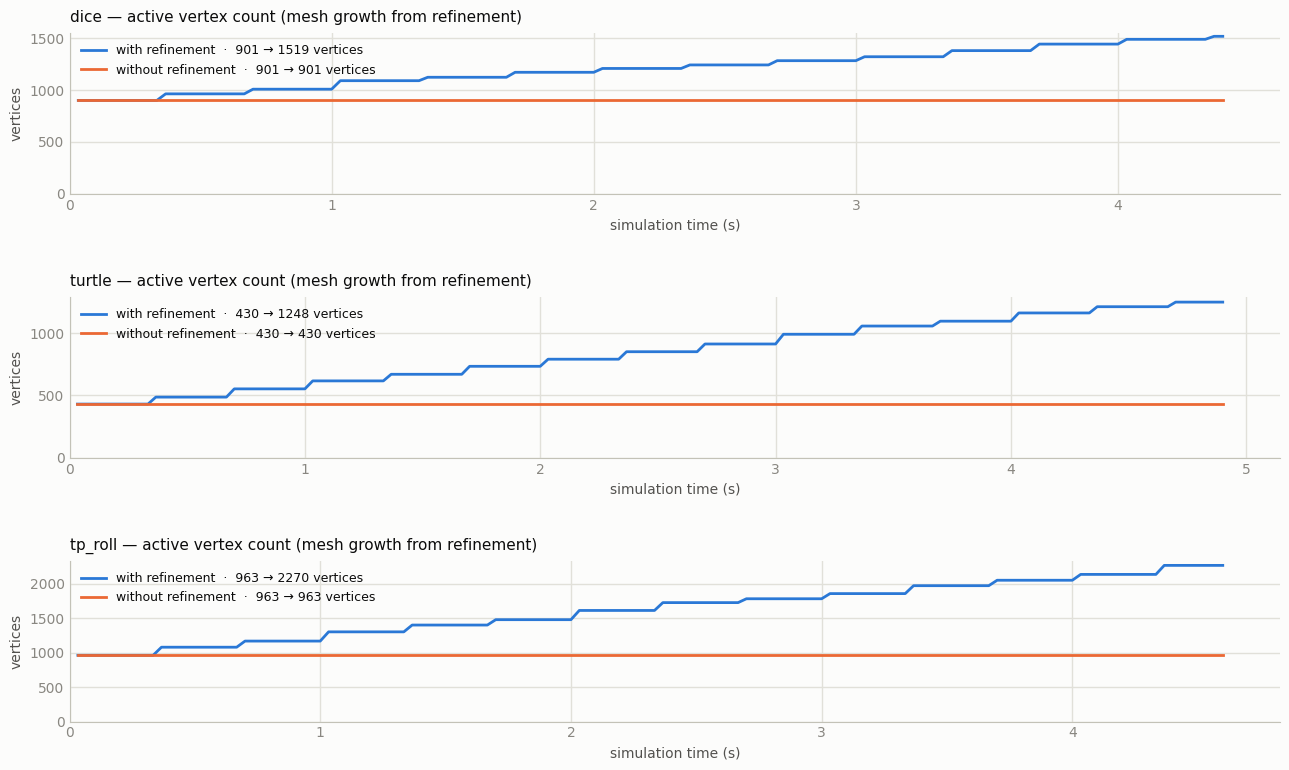

In [4]:
# Mesh growth for context: when and how much each run refines
fig, axes = plt.subplots(len(avail), 1, figsize=(13, 2.6 * len(avail)), squeeze=False)
for i, e in enumerate(avail):
    ax = axes[i][0]
    for label in RUNS[e]:
        p = RUNS[e][label][0]
        rec = _load_recording(p)
        n = [len(rec["positions_at"](k)) for k in range(rec["frame_count"])]
        ax.plot(rec["times"][:len(n)], n, color=SERIES[label], linewidth=2,
                label=f"{label}  ·  {n[0]} → {n[-1]} vertices")
    ax.set_title(f"{e} — active vertex count (mesh growth from refinement)", loc="left", fontsize=11, pad=8)
    ax.set_xlabel("simulation time (s)"); ax.set_ylabel("vertices")
    ax.set_xlim(0, None); ax.set_ylim(0, None); ax.tick_params(length=0)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout(h_pad=3); plt.show()

In [5]:
# Summary: episode-mean symmetric RMSE per run and reference, and the MSE change vs no refinement
rows = []
for e in avail:
    for ref in ("vs tracking", "vs fine simulation"):
        base = np.sqrt(stack(e, ref, "without refinement")[1].mean())
        key_fine = (e, ref, FINE_REF[e])
        if key_fine in curves:
            af = np.asarray(curves[key_fine]["mse_symmetric"], dtype=float)
            rows.append({"episode": e, "reference": ref, "run": FINE_LABEL,
                         "episode RMSE mm": episode_rmse_mm(af), "repeat spread mm": "single run",
                         "MSE change vs no refinement": f"{(af.mean() / base**2 - 1) * 100:+.0f}%"})
        for label in RUNS[e]:
            t, a = stack(e, ref, label)
            per_repeat = np.sqrt(a.mean(1)) * 1e3
            rows.append({
                "episode": e, "reference": ref, "run": label,
                "episode RMSE mm": episode_rmse_mm(a),
                "repeat spread mm": f"{per_repeat.min():.2f} – {per_repeat.max():.2f}",
                "MSE change vs no refinement": f"{(a.mean() / base**2 - 1) * 100:+.0f}%",
            })
pd.DataFrame(rows).round(2)

,episode,reference,run,episode RMSE mm,repeat spread mm,MSE change vs no refinement
0,dice,vs tracking,fine mesh (no refinement),3.84,single run,-43%
1,dice,vs tracking,with refinement,4.45,4.31 – 4.65,-23%
2,dice,vs tracking,without refinement,5.08,4.86 – 5.30,-0%
3,dice,vs fine simulation,with refinement,8.51,8.49 – 8.55,-1%
4,dice,vs fine simulation,without refinement,8.58,8.54 – 8.61,+0%
5,turtle,vs tracking,fine mesh (no refinement),10.39,single run,-0%
6,turtle,vs tracking,with refinement,10.11,9.88 – 10.30,-6%
7,turtle,vs tracking,without refinement,10.41,10.39 – 10.42,+0%
8,turtle,vs fine simulation,with refinement,5.80,5.50 – 6.08,-57%
9,turtle,vs fine simulation,without refinement,8.83,8.79 – 8.91,+0%
